# Object Detection For Autonomous Driving

## Objective

The goal of this assignment is to fine-tune the YOLO object detection model on a subset of the KITTI dataset, widely used in autonomous driving research. The KITTI dataset provides annotated images for tasks like object detection, tracking, and segmentation, making it ideal for training models to detect objects such as cars, pedestrians, and cyclists.

By completing this assignment, you will gain hands-on experience in dataset preparation, annotation conversion, model training, and performance evaluation using metrics like mAP (mean Average Precision). Additionally, you will explore the trade-offs between speed and accuracy, crucial for real-time applications like autonomous driving.


## Introduction: Object Detection

Object detection is a fundamental task in computer vision that involves identifying and localizing objects within an image or video.

The main techniques for object detection include traditional methods like sliding window and region-based approaches, as well as modern deep learning-based methods such as YOLO (You Only Look Once), SSD (Single Shot MultiBox Detector), and Faster R-CNN. These techniques leverage convolutional neural networks (CNNs) to extract features and predict bounding boxes and class labels for objects in real-time or near real-time.

Widely used models for object detection include:
- **YOLO (You Only Look Once)**: Known for its speed and efficiency in real-time applications.
- **Faster R-CNN**: A two-stage detector that provides high accuracy but is slower compared to single-stage detectors.
- **SSD (Single Shot MultiBox Detector)**: Balances speed and accuracy, making it suitable for various applications.
- **RetinaNet**: Introduces the focal loss to address class imbalance in object detection.
- **EfficientDet**: A family of models that optimize both accuracy and efficiency using compound scaling.

In the context of autonomous vehicles, object detection plays a critical role in perceiving the environment, identifying obstacles, pedestrians, traffic signs, and other vehicles. This capability enables autonomous systems to make informed decisions, ensuring safety and efficiency in navigation and driving scenarios.

## YOLO

YOLO (You Only Look Once) is a state-of-the-art, real-time object detection system. Unlike traditional object detection methods that apply a classifier to different regions of an image, YOLO frames object detection as a single regression problem. It predicts bounding boxes and class probabilities directly from full images in one evaluation, making it extremely fast and efficient.

### Model

The YOLO model divides the input image into a grid, where each grid cell is responsible for predicting bounding boxes and their associated class probabilities. Key features of YOLO include:

- **Unified Architecture**: YOLO uses a single convolutional neural network (CNN) to predict multiple bounding boxes and class probabilities simultaneously.
- **Speed**: YOLO is optimized for real-time applications, capable of processing images at high frame rates.
- **Global Context**: By considering the entire image during training and inference, YOLO reduces false positives and improves detection accuracy.
- **Versions**: Over time, YOLO has evolved through multiple versions (e.g., YOLOv1 up to YOLOv11), each introducing architectural improvements, better loss functions, and enhanced performance.

YOLO is widely used in applications such as autonomous driving, surveillance, and robotics, where real-time object detection is critical.

For more details on YOLO, visit the [Ultralytics GitHub repository](https://github.com/ultralytics/ultralytics).

## Theory Questions


For the next questions, focus on the latest version of the model, YOLOv11

Briefly describe the architecture used in YOLOv11 and the different losses used during training.

**Ans :**

The YOLOv11 architecture is composed of three main components: the **Backbone**, the **Neck**, and the **Head**.

**Backbone:**
The backbone is a convolutional neural network (CNN) used to extract features from the input images. YOLOv11 uses an optimized backbone designed to maximize the trade-off between speed and accuracy.

**Neck:**
The neck aggregates features at different scales to improve detection of objects of various sizes. It typically uses structures such as Feature Pyramid Networks (FPN) or Path Aggregation Networks (PAN).

**Head:**
The head produces the final predictions. In YOLOv11, a **decoupled head** is used: one branch is dedicated to classification, and the other to localization. This improves both accuracy and training stability.

---

### Loss Functions

YOLOv11 uses several loss functions during training:

**Localization loss:**
Measures the error between the predicted bounding boxes and the ground truth boxes. It is typically based on IoU-based metrics (e.g., CIoU).

**Classification loss:**
Evaluates the quality of class predictions. It is applied only to detected objects and commonly uses Binary Cross-Entropy (BCE).

**Objectness loss:**
Determines whether a predicted box contains an object or not. This is also usually computed using BCE.

**Focal loss:**
Sometimes used to address class imbalance by giving more or less weight to hard or misclassified examples.

What are the metrics used to assess YOLO's performance for object detection?

**ANS :**

**1)** We first evaluate the overlap between the predicted bounding box and the ground truth using **Intersection over Union (IoU)**, defined as:

$$
IoU = \frac{\text{area of overlap}}{\text{area of union}}
$$

A prediction is considered correct if the IoU exceeds a given threshold.

---

**2)** **Precision and Recall**:

* Precision measures how many predicted objects are correct.
* Recall measures how many real objects are correctly detected.

$$
Precision = \frac{TP}{TP + FP}
$$

$$
Recall = \frac{TP}{TP + FN}
$$

---

**3)** **Average Precision (AP) and mean Average Precision (mAP)**:
AP is computed from the Precision–Recall curve and represents the area under the curve for a single class.
mAP is the mean of AP over all classes.

---

**4)** **F1-score** harmonic mean of precision and recall:
$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

---

**5)** Finally, we can also consider the **latency** and the **inference speed** of the model, which are important for real-time performance.



## Code

In the next part of the assignment, you will load a YOLO model and fine-tune it on the provided subset of the KITTI dataset.
You will then visualize the training losses and evaluate the model by running inference to assess its performance.

In [6]:
!pip install ultralytics opencv-python-headless -q

In [7]:
import os, cv2, glob, random, shutil, requests, zipfile
from ultralytics import YOLO

import matplotlib.pyplot as plt
import pandas as pd
import os

%matplotlib inline

from IPython.display import Image, display
import glob

import yaml
import cv2
import matplotlib.pyplot as plt
import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:
# ---------------------------------------------
# STEP 1: Setup paths
# ---------------------------------------------
HOME = os.getcwd()
DATASET_PATH = os.path.join(HOME, "datasets", "kitti_subset")
IMAGES_PATH = os.path.join(DATASET_PATH, "images")
LABELS_PATH = os.path.join(DATASET_PATH, "labels")

TRAIN_IMG = os.path.join(IMAGES_PATH, "train")
VAL_IMG = os.path.join(IMAGES_PATH, "val")
TEST_IMG = os.path.join(IMAGES_PATH, "test")
TRAIN_LABEL = os.path.join(LABELS_PATH, "train")
VAL_LABEL = os.path.join(LABELS_PATH, "val")
TEST_LABEL = os.path.join(LABELS_PATH, "test")

for path in [TRAIN_IMG, VAL_IMG, TEST_IMG, TRAIN_LABEL, VAL_LABEL, TEST_LABEL]:
    os.makedirs(path, exist_ok=True)

# ---------------------------------------------
# STEP 2: Download and extract KITTI data
# ---------------------------------------------
KITTI_URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_image_2.zip"
KITTI_LABELS_URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_label_2.zip"

def download_and_extract(url, extract_to):
    zip_path = os.path.join(HOME, url.split("/")[-1])
    if not os.path.exists(zip_path):
        print(f"Downloading {url}...")
        response = requests.get(url, stream=True)
        with open(zip_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=1024):
                if chunk:
                    file.write(chunk)
        print("Download complete.")

    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Extraction complete.")

download_and_extract(KITTI_URL, IMAGES_PATH)
download_and_extract(KITTI_LABELS_URL, LABELS_PATH)

# ---------------------------------------------
# STEP 3: Convert KITTI annotations to YOLO
# ---------------------------------------------
CLASS_MAP = {"Car": 0, "Pedestrian": 1, "Cyclist": 2}

def convert_kitti_to_yolo(kitti_label_path, yolo_label_path, image_path):
    with open(kitti_label_path, "r") as file:
        lines = file.readlines()

    img = cv2.imread(image_path)
    if img is None:
        return
    height, width, _ = img.shape

    with open(yolo_label_path, "w") as yolo_file:
        for line in lines:
            elements = line.split()
            class_name = elements[0]
            if class_name not in CLASS_MAP:
                continue  # Skip irrelevant classes

            class_id = CLASS_MAP[class_name]
            x1, y1, x2, y2 = map(float, elements[4:8])

            # Convert to YOLO format
            center_x = ((x1 + x2) / 2) / width
            center_y = ((y1 + y2) / 2) / height
            bbox_width = (x2 - x1) / width
            bbox_height = (y2 - y1) / height

            yolo_file.write(f"{class_id} {center_x:.6f} {center_y:.6f} {bbox_width:.6f} {bbox_height:.6f}\n")

# ---------------------------------------------
# STEP 4: Prepare dataset (subset, split, convert)
# ---------------------------------------------
all_images = sorted(glob.glob(os.path.join(IMAGES_PATH, "training", "image_2", "*.png")))
all_labels = sorted(glob.glob(os.path.join(LABELS_PATH, "training", "label_2", "*.txt")))

paired_data = list(zip(all_images, all_labels))
random.seed(42)
random.shuffle(paired_data)

# Keep small subset (e.g., 300 images total)
subset_data = paired_data[:300]
train_size = int(0.8 * len(subset_data))
val_size = int(0.1 * len(subset_data))

train_data = subset_data[:train_size]
val_data = subset_data[train_size:train_size + val_size]
test_data = subset_data[train_size + val_size:]

def move_and_convert_files(data, img_dest, lbl_dest):
    for img_path, lbl_path in data:
        new_img_path = os.path.join(img_dest, os.path.basename(img_path))
        new_lbl_path = os.path.join(lbl_dest, os.path.basename(lbl_path))
        shutil.copy2(img_path, new_img_path)
        convert_kitti_to_yolo(lbl_path, new_lbl_path, new_img_path)

move_and_convert_files(train_data, TRAIN_IMG, TRAIN_LABEL)
move_and_convert_files(val_data, VAL_IMG, VAL_LABEL)
move_and_convert_files(test_data, TEST_IMG, TEST_LABEL)


# ---------------------------------------------
# STEP 5: Create data.yaml
# ---------------------------------------------
data_yaml = f"""
path: {DATASET_PATH}
train: images/train
val: images/val
test: images/test

nc: 3
names: ['Car', 'Pedestrian', 'Cyclist']
"""

with open(os.path.join(DATASET_PATH, "data.yaml"), "w") as f:
    f.write(data_yaml)



Download complete.
Extracting /content/data_object_image_2.zip...
Extraction complete.
Download complete.
Extracting /content/data_object_label_2.zip...
Extraction complete.


In [9]:
# ---------------------------------------------
# STEP 6: Fine-tune YOLOv11 model + choose best hyperparameters
# ---------------------------------------------

DATA_YAML_PATH = os.path.join(DATASET_PATH, "data.yaml")

configs = [
    {"lr0": 0.001,  "freeze": 10, "imgsz": 640},
    {"lr0": 0.0005, "freeze": 10, "imgsz": 640},
    {"lr0": 0.001,  "freeze": 0,  "imgsz": 640},
    {"lr0": 0.001,  "freeze": 10, "imgsz": 768},
]

all_results = []
best_score = -1.0
best_cfg = None
best_trial_name = None
best_model_path = None

for i, cfg in enumerate(configs):
    trial_name = f"trial_{i}"
    print(f"\n===== Training {trial_name} with config: {cfg} =====")

    model = YOLO("yolo11n.pt")

    model.train(
        data=DATA_YAML_PATH,
        epochs=50,
        batch=16,
        optimizer="AdamW",
        patience=20,
        project=os.path.join(HOME, "runs"),
        name=trial_name,
        pretrained=True,
        **cfg
    )

    trial_best_path = os.path.join(HOME, "runs", trial_name, "weights", "best.pt")
    trial_best_model = YOLO(trial_best_path)
    metrics = trial_best_model.val(data=DATA_YAML_PATH)

    map50 = float(metrics.box.map50)
    map5095 = float(metrics.box.map)
    precision = float(metrics.box.mp)
    recall = float(metrics.box.mr)

    score = map5095

    result = {
        "trial": trial_name,
        "config": cfg,
        "model_path": trial_best_path,
        "mAP50": map50,
        "mAP50_95": map5095,
        "precision": precision,
        "recall": recall,
        "score_used_for_selection": score
    }
    all_results.append(result)

    print(f"Results for {trial_name}:")
    print(f"  mAP50     = {map50:.4f}")
    print(f"  mAP50-95  = {map5095:.4f}")
    print(f"  Precision = {precision:.4f}")
    print(f"  Recall    = {recall:.4f}")

    if score > best_score:
        best_score = score
        best_cfg = cfg
        best_trial_name = trial_name
        best_model_path = trial_best_path

print("\n===================================")
print("BEST HYPERPARAMETER CONFIGURATION")
print("===================================")
print("Best trial :", best_trial_name)
print("Best config:", best_cfg)
print("Best model :", best_model_path)
print("Best score (mAP50-95):", round(best_score, 4))

print("\nAll trial results:")
for r in all_results:
    print(r)

best_model = YOLO(best_model_path)

# Final validation
metrics = best_model.val(data=DATA_YAML_PATH)
print("\nFinal best model metrics:")
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

# Predictions on test images
test_images = glob.glob(os.path.join(TEST_IMG, "*.png"))

predictions = best_model.predict(
    source=test_images[:5],
    imgsz=best_cfg["imgsz"],   # use the winning image size
    conf=0.25,
    save=True
)


===== Training trial_0 with config: {'lr0': 0.001, 'freeze': 10, 'imgsz': 640} =====
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/kitti_subset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=trial_

# Inference

After training, visualize the losses andmetrics calculated on the validation set during training.

Additionally, make sure you visualize the confusion matrix to see per-class errors.

For qualitative analysis, run inference on the model, visualise the bouding boxes and visually assess it.

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


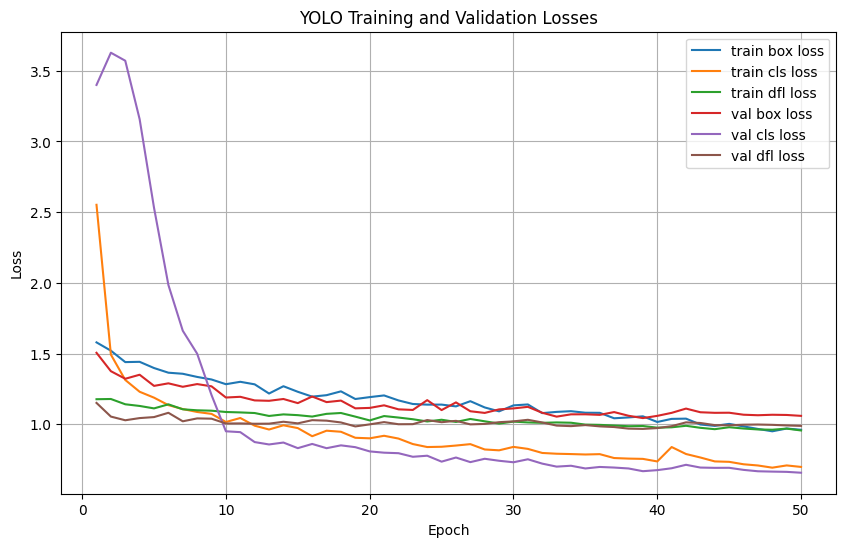

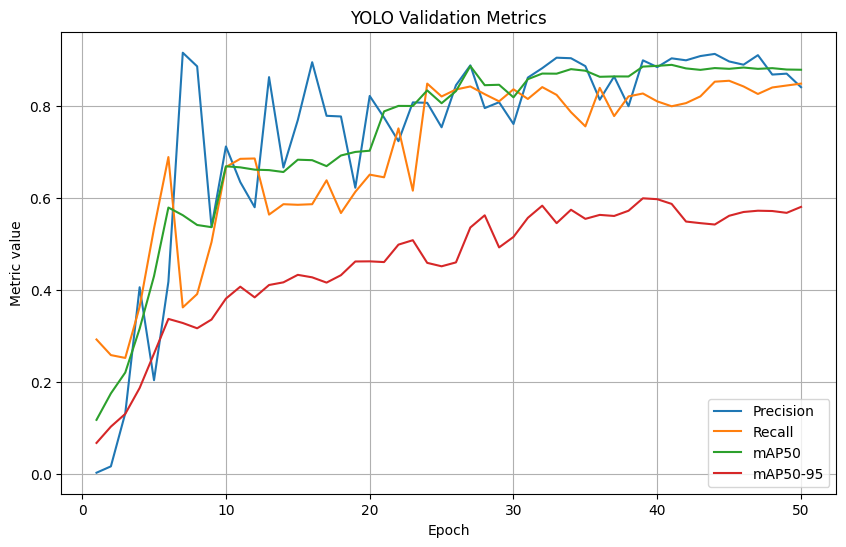

In [13]:
# -------- VISUALIZE TRAINING LOSSES AND METRICS --------
#TO-DO: Add the code to visualize the training losses and metrics

results_csv = os.path.join(HOME, "runs", best_trial_name, "results.csv")

df = pd.read_csv(results_csv)
print(df.columns)

df.columns = [c.strip() for c in df.columns]

# -------- Plot training and validation losses --------
plt.figure(figsize=(10, 6))
plt.plot(df["epoch"], df["train/box_loss"], label="train box loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="train cls loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="train dfl loss")

if "val/box_loss" in df.columns:
    plt.plot(df["epoch"], df["val/box_loss"], label="val box loss")
if "val/cls_loss" in df.columns:
    plt.plot(df["epoch"], df["val/cls_loss"], label="val cls loss")
if "val/dfl_loss" in df.columns:
    plt.plot(df["epoch"], df["val/dfl_loss"], label="val dfl loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLO Training and Validation Losses")
plt.legend()
plt.grid(True)
plt.show()

# -------- Plot main metrics --------
plt.figure(figsize=(10, 6))

if "metrics/precision(B)" in df.columns:
    plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
if "metrics/recall(B)" in df.columns:
    plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
if "metrics/mAP50(B)" in df.columns:
    plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
if "metrics/mAP50-95(B)" in df.columns:
    plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")

plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("YOLO Validation Metrics")
plt.legend()
plt.grid(True)
plt.show()

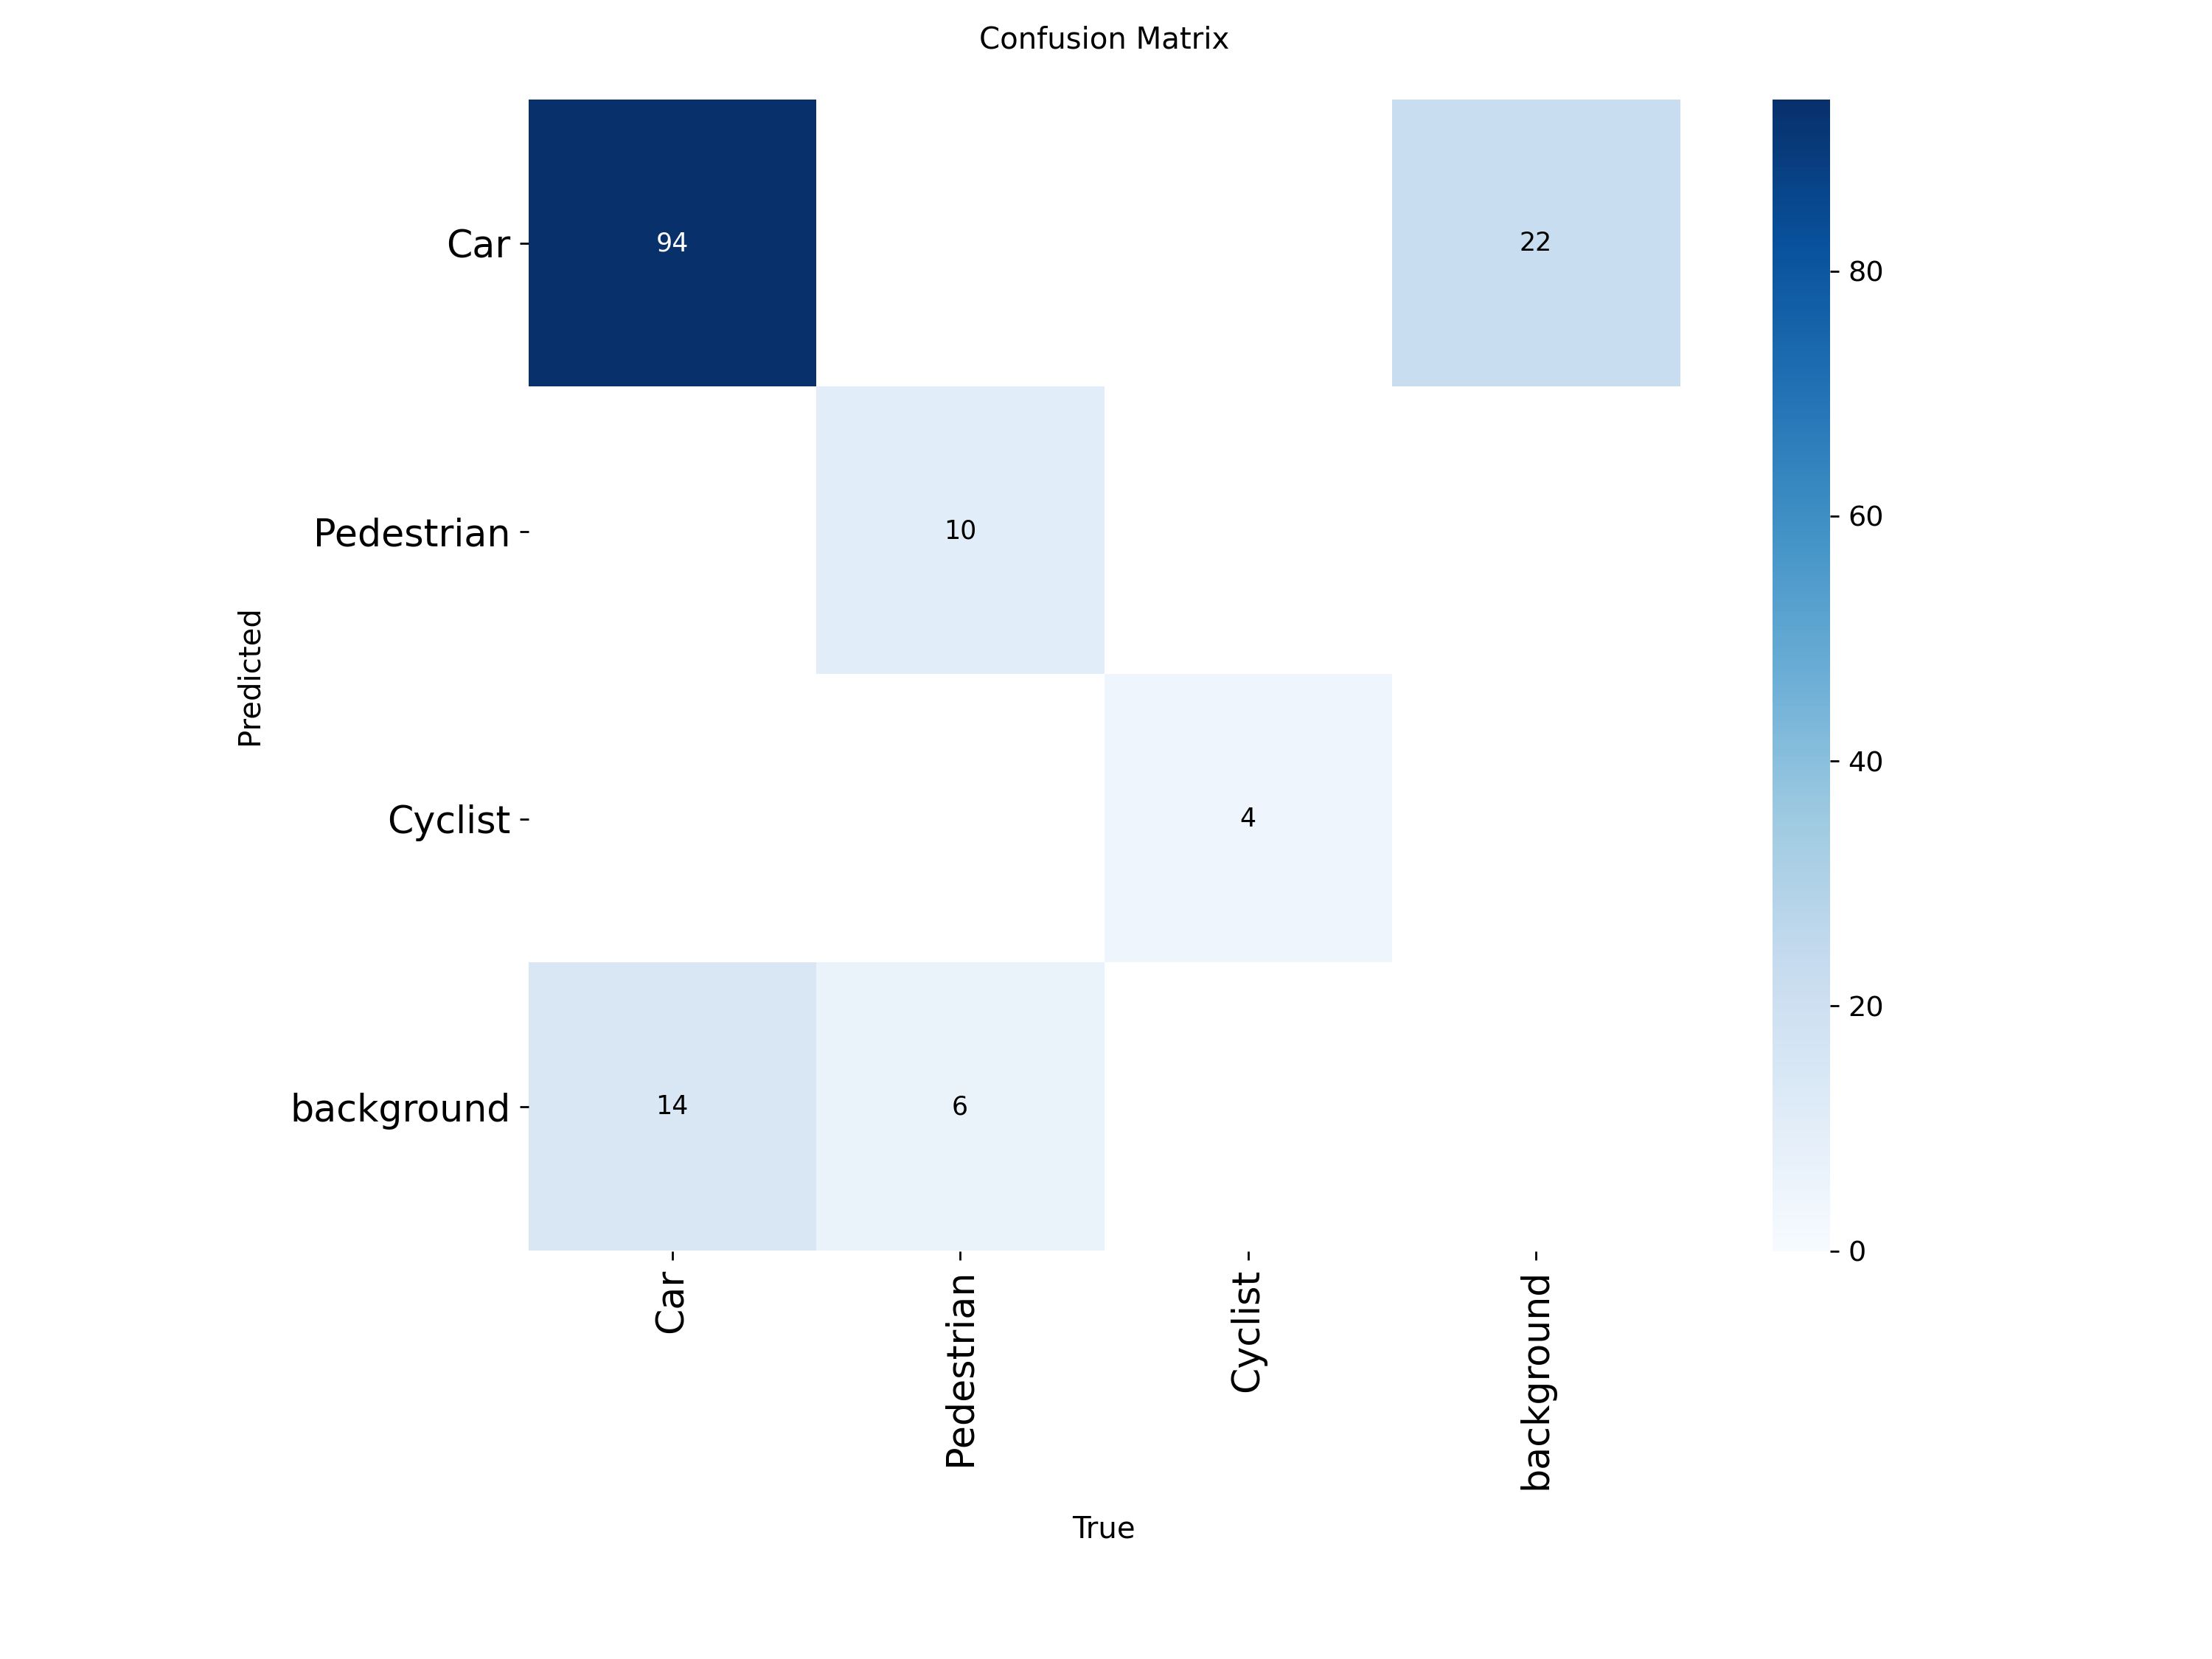

In [14]:
# ------ VISUALIZE CONFUSION MATRIX --------
#TO-DO: Add the code to visualize the confusion matrix

conf_matrix_path = os.path.join(HOME, "runs", best_trial_name, "confusion_matrix.png")

display(Image(filename=conf_matrix_path))


0: 768x768 2 Cars, 7.3ms
1: 768x768 4 Cars, 7.3ms
2: 768x768 4 Pedestrians, 7.3ms
3: 768x768 7 Cars, 7.3ms
4: 768x768 4 Cars, 7.3ms
Speed: 3.4ms preprocess, 7.3ms inference, 1.0ms postprocess per image at shape (1, 3, 768, 768)


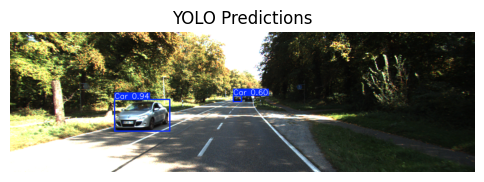

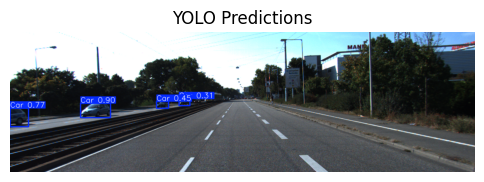

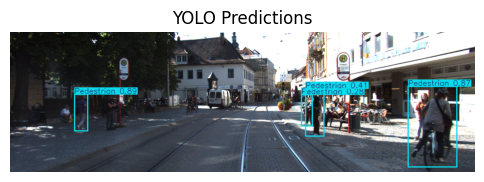

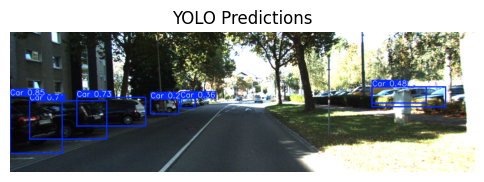

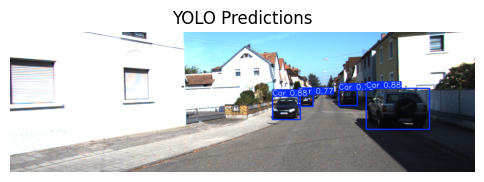

In [15]:
# -------- RUN INFERENCE AND PLOT SAMPLE OUTPUTS --------
#TO-DO: Add the code to run inference and visualize the outputs results

test_images = glob.glob(os.path.join(TEST_IMG, "*.png"))

results = best_model.predict(
    source=test_images[:5],
    imgsz=best_cfg["imgsz"],
    conf=0.25,
    save=False
)

# Display results
for r in results:
    img = r.plot()

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("YOLO Predictions")
    plt.show()


## Question

Comment on the performance of the model based on the visualizations you made and discuss the inference speed versus performance for YOLO on the driving datasets. Do you think we can use YOLO online on autonomous cars?

## Ans

Independatly of the security